In [1]:
from google.colab import drive
import os
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
import torch
import torch.nn as nn
import torch.distributions as dist

print("Connecting to Google Drive...")
drive.mount('/content/drive')

# Define the path to the zip file
zip_path = "/content/drive/MyDrive/m5-forecasting-uncertainty.zip"
extract_path = "/content/m5_data/"

# Unzip the file into Colab's local storage
print("\nExtracting massive M5 dataset to local Colab runtime...")
!unzip -q "{zip_path}" -d "{extract_path}"

# Verify it worked
if os.path.exists(extract_path):
    print("\nSuccess! Here are the files ready for your PyTorch model:")
    print(os.listdir(extract_path))
else:
    print("Could not find the zip file. Check your Google Drive folder name.")

Connecting to Google Drive...
Mounted at /content/drive

Extracting massive M5 dataset to local Colab runtime...
Mounted at /content/drive

Extracting massive M5 dataset to local Colab runtime...

Success! Here are the files ready for your PyTorch model:
['sell_prices.csv', 'sales_train_validation.csv', 'sales_train_evaluation.csv', 'sample_submission.csv', 'calendar.csv']

Success! Here are the files ready for your PyTorch model:
['sell_prices.csv', 'sales_train_validation.csv', 'sales_train_evaluation.csv', 'sample_submission.csv', 'calendar.csv']


In [2]:
import pandas as pd
import numpy as np
import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader

# ==========================================
# 1. CONFIGURATION
# ==========================================
STORE_ID = 'CA_1'
SEQ_LEN = 28          # Look back 28 days
PRED_LEN = 1          # Predict 1 day ahead (can be expanded to 28)
BATCH_SIZE = 256
EPOCHS = 5
LEARNING_RATE = 1e-3

QUANTILES = [0.005, 0.025, 0.165, 0.250, 0.500, 0.750, 0.835, 0.975, 0.995]

# ==========================================
# 2. TIME-BASED DATASET GENERATOR
# ==========================================
class M5TimeDataset(Dataset):
    def __init__(self, df, start_col_idx, end_col_idx, seq_len):
        """
        Extracts a chronological slice of the data for training or validation.
        """
        # Extract only the day columns we want for this time split
        self.data = df.iloc[:, start_col_idx:end_col_idx].values.astype(np.float32)
        self.seq_len = seq_len
        self.num_items, self.total_days = self.data.shape

        # Calculate how many sliding windows we can make per item
        self.windows_per_item = self.total_days - self.seq_len

    def __len__(self):
        return self.num_items * self.windows_per_item

    def __getitem__(self, idx):
        # Map a flat 1D index back to a specific item and time window
        item_idx = idx // self.windows_per_item
        time_idx = idx % self.windows_per_item

        # X: Past `seq_len` days
        X = self.data[item_idx, time_idx : time_idx + self.seq_len]
        # Y: The very next day
        Y = self.data[item_idx, time_idx + self.seq_len]

        # PyTorch LSTMs expect feature dimension at the end: (seq_len, num_features)
        X = torch.tensor(X).unsqueeze(-1)
        Y = torch.tensor(Y)
        return X, Y

# ==========================================
# 3. PROBABILISTIC LSTM MODEL
# ==========================================
class QuantileLSTM(nn.Module):
    def __init__(self, input_size=1, hidden_size=64, num_layers=2, num_quantiles=9):
        super(QuantileLSTM, self).__init__()
        self.lstm = nn.LSTM(input_size, hidden_size, num_layers, batch_first=True)
        # The linear layer outputs 9 values (one for each quantile)
        self.fc = nn.Linear(hidden_size, num_quantiles)

    def forward(self, x):
        # x shape: (batch_size, seq_len, input_size)
        lstm_out, _ = self.lstm(x)

        # We only care about the output of the final time step
        final_step_out = lstm_out[:, -1, :]

        # out shape: (batch_size, 9)
        out = self.fc(final_step_out)
        return out

# ==========================================
# 4. PINBALL LOSS FUNCTION
# ==========================================
def pinball_loss(preds, target, quantiles):
    """
    preds: (batch_size, 9)
    target: (batch_size)
    """
    target = target.unsqueeze(1) # shape: (batch_size, 1)
    loss = 0.0

    for i, q in enumerate(quantiles):
        error = target - preds[:, i:i+1]
        # Max of q * error and (q-1) * error
        loss += torch.max(q * error, (q - 1) * error).mean()

    return loss / len(quantiles)

# ==========================================
# 5. EXECUTION & TRAINING LOOP
# ==========================================
print("Loading Data...")
df_eval = pd.read_csv('m5_data/sales_train_evaluation.csv')

# Filter for prototype store
df_store = df_eval[df_eval['store_id'] == STORE_ID].copy()
day_cols = [col for col in df_store.columns if col.startswith('d_')]
df_store = df_store[['id'] + day_cols]

# Find column indices for time splitting
start_idx = df_store.columns.get_loc('d_1')
end_idx = df_store.columns.get_loc('d_1941') + 1

# -- TIME SPLIT --
# Let's use the last 100 days for validation, and everything before it for training
split_point = end_idx - 100

print("Building Time-Based PyTorch Datasets...")
train_dataset = M5TimeDataset(df_store, start_col_idx=start_idx, end_col_idx=split_point, seq_len=SEQ_LEN)
val_dataset = M5TimeDataset(df_store, start_col_idx=split_point - SEQ_LEN, end_col_idx=end_idx, seq_len=SEQ_LEN)

train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True, num_workers=2)
val_loader = DataLoader(val_dataset, batch_size=BATCH_SIZE, shuffle=False)

# Initialize Model, Optimizer
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
model = QuantileLSTM().to(device)
optimizer = torch.optim.Adam(model.parameters(), lr=LEARNING_RATE)

print(f"\nStarting Training on {device}...")
for epoch in range(EPOCHS):
    # --- TRAINING ---
    model.train()
    train_loss = 0.0

    for batch_idx, (X, Y) in enumerate(train_loader):
        X, Y = X.to(device), Y.to(device)

        optimizer.zero_grad()
        preds = model(X)
        loss = pinball_loss(preds, Y, QUANTILES)
        loss.backward()
        optimizer.step()

        train_loss += loss.item()

        if batch_idx % 500 == 0 and batch_idx > 0:
            print(f"  Epoch {epoch+1} | Batch {batch_idx} | Train Loss: {loss.item():.4f}")

    # --- VALIDATION ---
    model.eval()
    val_loss = 0.0
    with torch.no_grad():
        for X, Y in val_loader:
            X, Y = X.to(device), Y.to(device)
            preds = model(X)
            loss = pinball_loss(preds, Y, QUANTILES)
            val_loss += loss.item()

    avg_train_loss = train_loss / len(train_loader)
    avg_val_loss = val_loss / len(val_loader)

    print(f"=== EPOCH {epoch+1} SUMMARY: Train Loss: {avg_train_loss:.4f} | Val Loss: {avg_val_loss:.4f} ===")

Loading Data...
Loading Data...
Building Time-Based PyTorch Datasets...
Building Time-Based PyTorch Datasets...

Starting Training on cuda...

Starting Training on cuda...
  Epoch 1 | Batch 500 | Train Loss: 0.2652
  Epoch 1 | Batch 500 | Train Loss: 0.2652
  Epoch 1 | Batch 1000 | Train Loss: 0.2432
  Epoch 1 | Batch 1000 | Train Loss: 0.2432
  Epoch 1 | Batch 1500 | Train Loss: 0.2260
  Epoch 1 | Batch 1500 | Train Loss: 0.2260
  Epoch 1 | Batch 2000 | Train Loss: 0.2776
  Epoch 1 | Batch 2000 | Train Loss: 0.2776
  Epoch 1 | Batch 2500 | Train Loss: 0.1875
  Epoch 1 | Batch 2500 | Train Loss: 0.1875
  Epoch 1 | Batch 3000 | Train Loss: 0.1803
  Epoch 1 | Batch 3000 | Train Loss: 0.1803
  Epoch 1 | Batch 3500 | Train Loss: 0.2017
  Epoch 1 | Batch 3500 | Train Loss: 0.2017
  Epoch 1 | Batch 4000 | Train Loss: 0.2185
  Epoch 1 | Batch 4000 | Train Loss: 0.2185
  Epoch 1 | Batch 4500 | Train Loss: 0.1833
  Epoch 1 | Batch 4500 | Train Loss: 0.1833
  Epoch 1 | Batch 5000 | Train Loss: 0

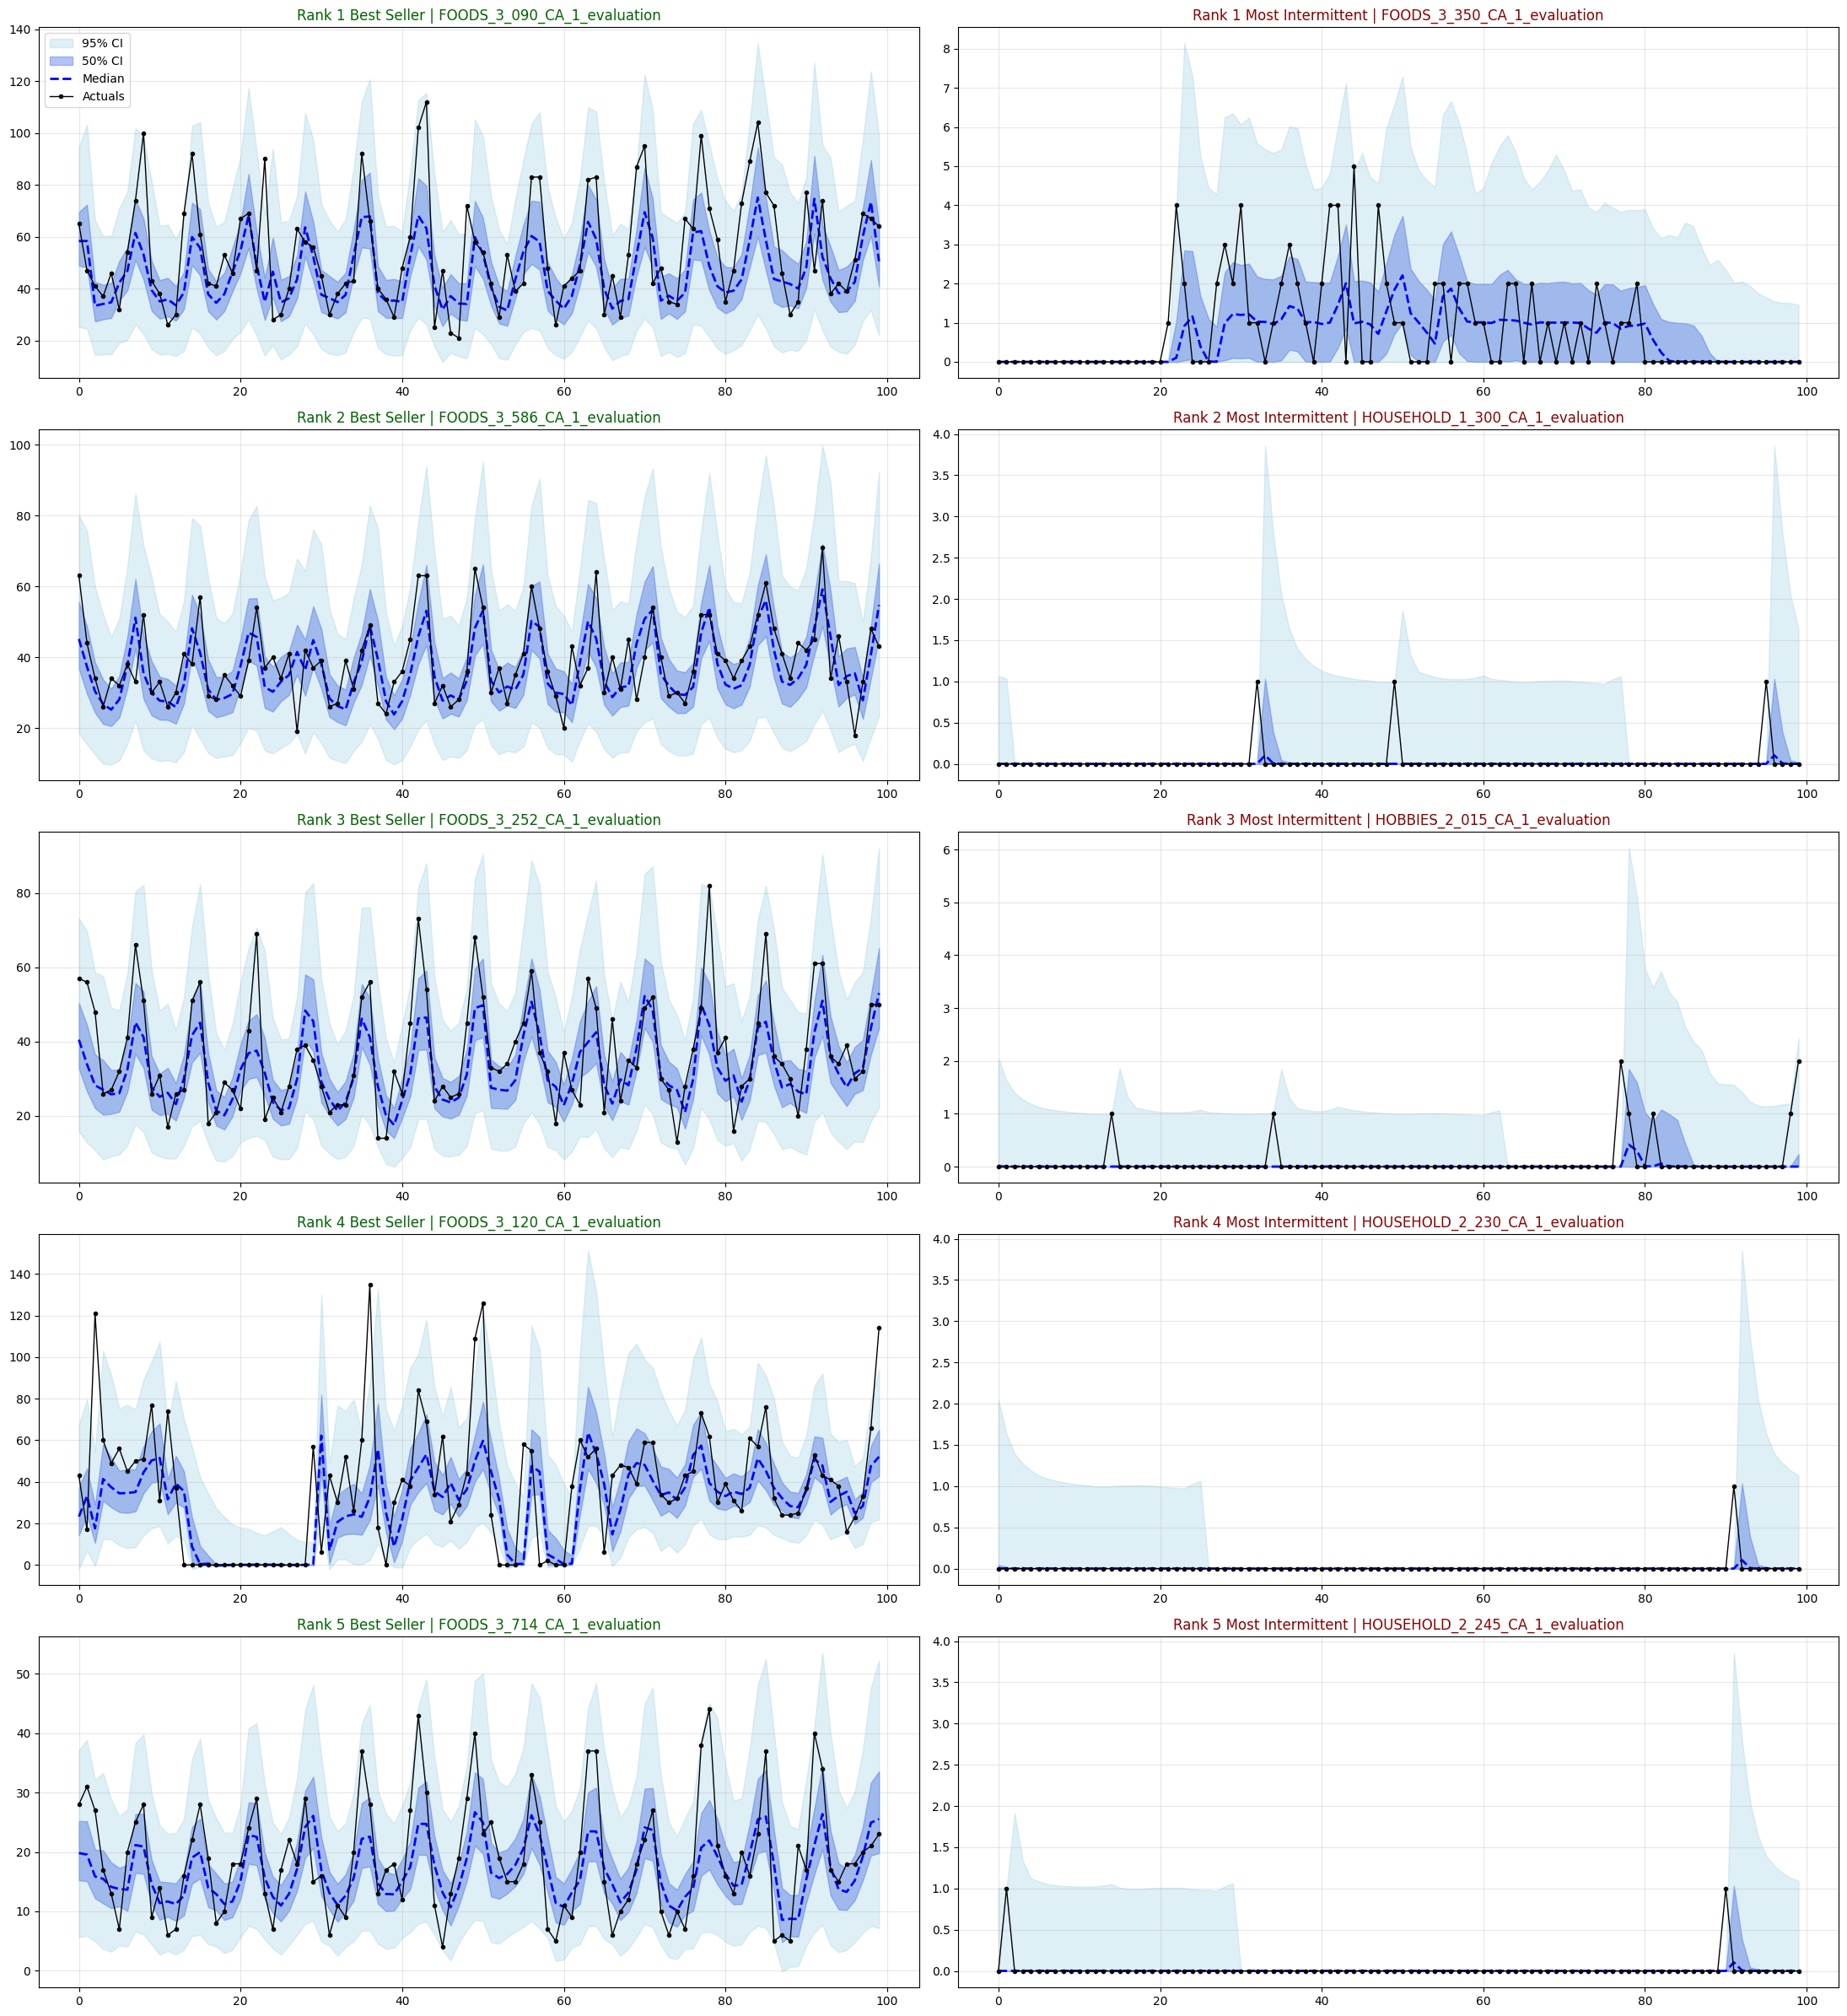

In [5]:
import matplotlib.pyplot as plt
import numpy as np
import torch

def get_best_and_worst_indices(df_store, day_cols):
    """
    Analyzes the raw store dataframe to find the integer indices
    (which match the PyTorch dataset) of the top 5 and bottom 5 items.
    """
    total_sales = df_store[day_cols].sum(axis=1).values
    zero_rates = (df_store[day_cols] == 0).mean(axis=1).values

    # 1. Top 5 Best Sellers (Highest Volume)
    top_5_indices = total_sales.argsort()[::-1][:5].tolist()

    # 2. Top 5 Poorest Sellers (High Zero Rate, but at least 50 total sales so they aren't totally dead)
    active_mask = total_sales > 50
    # Mask out inactive items by giving them a negative zero rate temporarily
    masked_zero_rates = np.where(active_mask, zero_rates, -1)
    poor_5_indices = masked_zero_rates.argsort()[::-1][:5].tolist()

    return top_5_indices, poor_5_indices

def visualize_best_vs_worst_grid(model, dataset, top_5_idx, poor_5_idx, quantiles, df_store, device='cuda'):
    """
    Plots the Top 5 items on the left and the Top 5 Intermittent items on the right.
    """
    model.eval()

    # Get quantile indices
    idx_025 = quantiles.index(0.025)
    idx_250 = quantiles.index(0.250)
    idx_500 = quantiles.index(0.500) # Median
    idx_750 = quantiles.index(0.750)
    idx_975 = quantiles.index(0.975)

    # Set up the Matplotlib grid (5 rows, 2 columns)
    fig, axes = plt.subplots(nrows=5, ncols=2, figsize=(22, 24))

    # Add column titles
    axes[0, 0].set_title("🏆 TOP 5 HIGH-VOLUME ITEMS (Dense Data)", fontsize=16, fontweight='bold', pad=20)
    axes[0, 1].set_title("👻 TOP 5 INTERMITTENT ITEMS (Sparse Data)", fontsize=16, fontweight='bold', pad=20)

    with torch.no_grad():
        for row in range(5):
            # We process the Good item for the Left Column, and Poor item for the Right Column
            for col, item_idx in enumerate([top_5_idx[row], poor_5_idx[row]]):

                start_idx = item_idx * dataset.windows_per_item
                end_idx = start_idx + dataset.windows_per_item

                # Grab all time steps for this item
                X_all = []
                Y_all = []
                for i in range(start_idx, end_idx):
                    x, y = dataset[i]
                    X_all.append(x)
                    Y_all.append(y.item())

                X_batch = torch.stack(X_all).to(device)
                preds = model(X_batch).cpu().numpy()

                time_steps = range(len(Y_all))
                ax = axes[row, col]

                # Plot 95% CI
                ax.fill_between(time_steps, preds[:, idx_025], preds[:, idx_975],
                                color='lightblue', alpha=0.4, label='95% CI')
                # Plot 50% CI
                ax.fill_between(time_steps, preds[:, idx_250], preds[:, idx_750],
                                color='royalblue', alpha=0.4, label='50% CI')
                # Plot Median
                ax.plot(time_steps, preds[:, idx_500], color='blue', linestyle='--',
                        linewidth=2, label='Median')
                # Plot Actuals
                ax.plot(time_steps, Y_all, color='black', marker='o',
                        markersize=3, label='Actuals', linewidth=1)

                # Get the actual item string ID (e.g., 'FOODS_3_090_CA_1') for the subtitle
                item_string_id = df_store.iloc[item_idx]['id']

                if col == 0:
                    ax.set_title(f'Rank {row+1} Best Seller | {item_string_id}', fontsize=12, color='darkgreen')
                else:
                    ax.set_title(f'Rank {row+1} Most Intermittent | {item_string_id}', fontsize=12, color='darkred')

                ax.grid(True, alpha=0.3)

                # Only put legend on the very first chart to keep the grid clean
                if row == 0 and col == 0:
                    ax.legend(loc='upper left')

    plt.tight_layout()
    plt.show()

# --- HOW TO RUN IT ---
# 1. First, get the specific indices using your df_store dataframe
day_cols = [col for col in df_store.columns if col.startswith('d_')]
top_5, poor_5 = get_best_and_worst_indices(df_store, day_cols)

# 2. Run the visualization grid
visualize_best_vs_worst_grid(model, val_dataset, top_5, poor_5, QUANTILES, df_store, device=device)